In [1]:
from impact import Impact

from distgen import Generator

import os 

ROOT = os.environ['LCLS_LATTICE']

In [2]:
# Nicer plotting
import matplotlib.pyplot as plt
import matplotlib
%matplotlib inline
%config InlineBackend.figure_format = 'retina'
matplotlib.rcParams['figure.figsize'] = (8,4)

In [3]:
ifile = os.path.join(ROOT, 'impact/models/cu_inj/ImpactT.in')
gfile = os.path.join(ROOT, 'distgen/models/cu_inj/distgen.yaml')
assert os.path.exists(ifile)
assert os.path.exists(gfile)


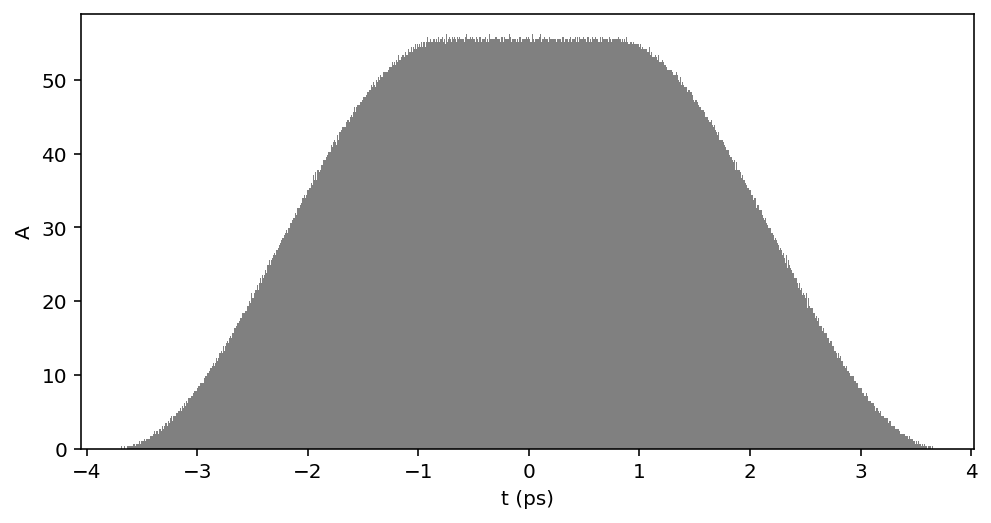

In [4]:
G = Generator(gfile)
G.run()
P0 = G.particles
P0.plot('t')

In [5]:
# Make Impact object
I = Impact(ifile, initial_particles = P0, verbose=True)

================ Impact-T Summary ================    
10000 particles
1 bunch of electrons
total charge: 249.99999999999997 pC
Distribution type: read
Cathode start at z = 0 m
   emission time: 1.4e-11 s
   image charges neglected after z = 0.02 m
Processor domain: 1 x 1 = 1 CPUs
Space charge grid: 16 x 16 x 16
Maximum time steps: 1000000
Reference Frequency: 2856000000.0 Hz
Initial reference time: 0.0 s
Simulation starting from the beginning

Configured to run in: /var/folders/wj/lfgr01993dx79p9cm_skykbw0000gn/T/tmp237fujc_


# Autophase

In [6]:
from impact.autophase import autophase_and_scale

from pmd_beamphysics import single_particle

P0 = single_particle(pz=1e-15, z=1e-15)

autophase_and_scale(I, phase_ele_name='GUN', target=6e6, scale_range=(10e6, 100e6), initial_particles=P0, verbose=False)

(304.83485070005105, 47541430.82645669)

In [7]:
#  Changes in phases
I.add_group('L0A', ele_names=['L0A_entrance', 'L0A_body_1', 'L0A_body_2', 'L0A_exit'], var_name='theta0_deg', attributes='theta0_deg')
I.add_group('L0B', ele_names=['L0B_entrance', 'L0B_body_1', 'L0B_body_2', 'L0B_exit'], var_name='theta0_deg', attributes='theta0_deg')

# Overall scaling, respecting the special factors. 
I.add_group('L0A_scale', ele_names=['L0A_entrance', 'L0A_body_1', 'L0A_body_2', 'L0A_exit'],
                   var_name = 'rf_field_scale',
                  factors = [0.86571945106805, 1, 1, 0.86571945106805],  # sin(k*d) with d = 3.5e-2 m 
                  absolute=True)

# Overall scaling, respecting the special factors. 
I.add_group('L0B_scale', ele_names=['L0B_entrance', 'L0B_body_1', 'L0B_body_2', 'L0B_exit'],
                   var_name = 'rf_field_scale',
                  factors = [0.86571945106805, 1, 1, 0.86571945106805],  # sin(k*d) with d = 3.5e-2 m 
                  absolute=True)

I['L0A_scale']['rf_field_scale'] = 30e6
I['L0A_scale']




ControlGroup(**{"ele_names": ["L0A_entrance", "L0A_body_1", "L0A_body_2", "L0A_exit"], "var_name": "rf_field_scale", "attributes": ["rf_field_scale", "rf_field_scale", "rf_field_scale", "rf_field_scale"], "factors": [0.86571945106805, 1, 1, 0.86571945106805], "absolute": true, "value": 30000000.0})

In [9]:
# L0A to 64 MeV
autophase_and_scale(I, phase_ele_name='L0A', scale_ele_name='L0A_scale', target=64e6, scale_range=(10e6, 100e6), initial_particles=P0, verbose=False)

(0.0015394116397828839, 30048347.359377533)

In [10]:
# L0B to 135 MeV
autophase_and_scale(I, phase_ele_name='L0B', scale_ele_name='L0B_scale', target=135e6, scale_range=(10e6, 100e6), initial_particles=P0, verbose=False)

(359.9999944625912, 36780527.390095934)

In [13]:
I.verbose=False
I.track(P0, s=8.371612)['mean_energy']

134999242.34121263

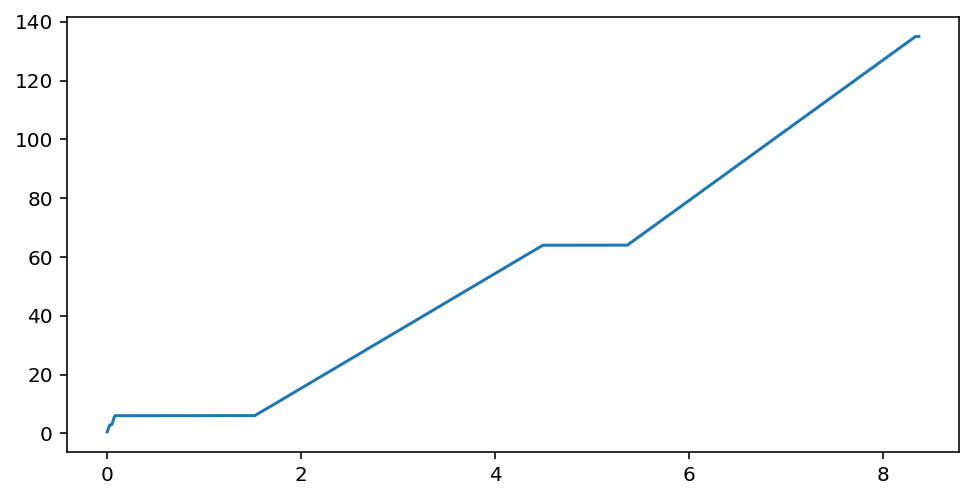

In [12]:
plt.plot(I.stat('mean_z'), I.stat('mean_kinetic_energy')/1e6 + 0.511)

# Parallel run

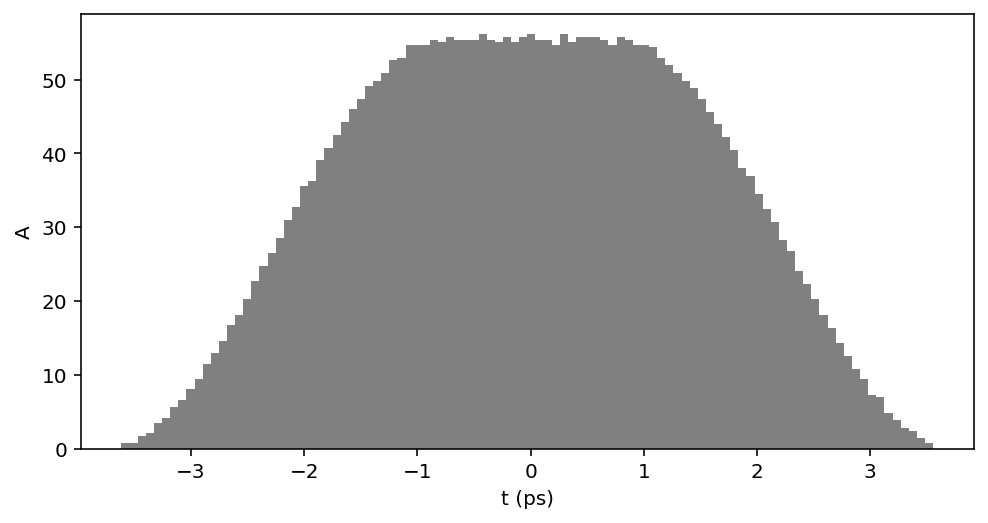

In [15]:
G = Generator(gfile)
G['n_particle'] = 10000
G.run()
P0 = G.particles
P0.plot('t')

In [18]:
I = Impact(ifile, initial_particles = P0, verbose=False, use_tempdir=False, workdir='/Users/chrisonian/Scratch/temp')

In [20]:
# Change some things
I.header['Nx'] = 64
I.header['Ny'] = 64
I.header['Nz'] = 128
I.header['Dt'] = 5e-13
I.stop = 15

# Set parallel domain
I.header['Npcol'] = 4
I.header['Nprow'] = 8

# Turn on MPI switches
I.use_mpi=True
I.impact_bin = '$IMPACTT_MPI_BIN'
I.mpi_exe = 'mpirun' 

I.write_input()